# 🤖 Notebook 2: The Vibe Coding Lab ⭐
**DigiHaz Doctoral Training Programme — Module 7: AI-Assisted IoT Development**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Digihaz/digihaz-course-materials/blob/dev/module_07_iot_sensor_networks/topic_04/notebooks/02_vibe_coding_lab.ipynb)

---

**This is the assessed workshop assignment.** You will critically evaluate four AI-generated solutions to the same IoT task, identify their bugs, and reflect on which parts of IoT code you can trust to an LLM and which you must verify.

The four solutions are real outputs that were produced by asking different LLMs the same prompt. Some work. Some have subtle bugs. Some look fine but produce nonsense.

**Your job:** find the bugs, classify each according to the five failure modes, and write a reflection.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PURPLE='#3D3780'; RED='#E63946'; ORANGE='#E07B24'
GREEN='#16A34A';  BLUE='#0A6EBD'; DARK='#1C1C2E'

print('✅ Setup complete')

✅ Setup complete


---
## The Original Prompt

Imagine you asked an LLM (Claude / ChatGPT / Copilot — pick any) the following question:

> *"Write a Python function `read_soil_moisture(raw_adc)` that converts the raw ADC reading from a capacitive soil moisture sensor on an ESP32 into a percentage from 0 to 100. The sensor outputs ADC ~3300 in completely dry soil and ADC ~1200 in saturated soil. The function should return a float between 0 and 100."*

Below are **four different answers** that an LLM might generate. Your job is to find what's wrong with each one.

---

## Solution A — *Most Confident, Looks Clean*

In [2]:
def read_soil_moisture_A(raw_adc):
    """Convert raw ADC reading to soil moisture percentage."""
    DRY_VALUE = 3300
    WET_VALUE = 1200
    percentage = (raw_adc - DRY_VALUE) / (WET_VALUE - DRY_VALUE) * 100
    return percentage

# Test it
test_values = [3300, 1200, 2250, 4000, 800, 2500]
print('Solution A results:')
for v in test_values:
    print(f'  raw_adc={v:5}  →  {read_soil_moisture_A(v):7.2f}%')

Solution A results:
  raw_adc= 3300  →    -0.00%
  raw_adc= 1200  →   100.00%
  raw_adc= 2250  →    50.00%
  raw_adc= 4000  →   -33.33%
  raw_adc=  800  →   119.05%
  raw_adc= 2500  →    38.10%


## Solution B — *Uses NumPy*

In [3]:
def read_soil_moisture_B(raw_adc):
    """Convert raw ADC value to soil moisture percentage using clamping."""
    dry, wet = 3300, 1200
    # Linear map: dry → 0%, wet → 100%
    pct = 100 * (dry - raw_adc) / (dry - wet)
    return np.clip(pct, 0, 100)

print('Solution B results:')
for v in test_values:
    print(f'  raw_adc={v:5}  →  {read_soil_moisture_B(v):7.2f}%')

Solution B results:
  raw_adc= 3300  →     0.00%
  raw_adc= 1200  →   100.00%
  raw_adc= 2250  →    50.00%
  raw_adc= 4000  →     0.00%
  raw_adc=  800  →   100.00%
  raw_adc= 2500  →    38.10%


## Solution C — *More Defensive Code*

In [7]:
def read_soil_moisture_C(raw_adc):
    """Robust soil moisture reading with input validation."""
    DRY_ADC = 3300
    WET_ADC = 1200
    if not isinstance(raw_adc, (int, float, np.number)):
        raise TypeError(f'raw_adc must be numeric, got {type(raw_adc)}')
    # Calibration check
    if raw_adc > DRY_ADC * 1.2 or raw_adc < WET_ADC * 0.5:
        return None  # sensor probably disconnected
    pct = 100 * (DRY_ADC - raw_adc) / (DRY_ADC - WET_ADC)
    return max(0.0, min(100.0, float(pct)))

print('Solution C results:')
for v in test_values:
    r = read_soil_moisture_C(v)
    print(f'  raw_adc={v:5}  →  {r}')

Solution C results:
  raw_adc= 3300  →  0.0
  raw_adc= 1200  →  100.0
  raw_adc= 2250  →  50.0
  raw_adc= 4000  →  None
  raw_adc=  800  →  100.0
  raw_adc= 2500  →  38.095238095238095


## Solution D — *"Improved Accuracy"*

In [8]:
def read_soil_moisture_D(raw_adc):
    """
    Soil moisture with non-linear correction for capacitive sensors.
    Uses an empirically-derived polynomial for better accuracy.
    """
    DRY = 3300
    WET = 1200
    # Linear baseline
    linear_pct = 100 * (DRY - raw_adc) / (DRY - WET)
    # "Non-linear correction" — note the polynomial coefficients
    corrected = linear_pct + 0.005 * (linear_pct ** 2) - 0.0001 * (linear_pct ** 3)
    return max(0.0, min(100.0, corrected))

print('Solution D results:')
for v in test_values:
    print(f'  raw_adc={v:5}  →  {read_soil_moisture_D(v):7.2f}%')

Solution D results:
  raw_adc= 3300  →     0.00%
  raw_adc= 1200  →    50.00%
  raw_adc= 2250  →    50.00%
  raw_adc= 4000  →     0.00%
  raw_adc=  800  →    21.19%
  raw_adc= 2500  →    39.82%


---
## Side-by-Side Comparison

Let's plot all four solutions against the **expected** behaviour (a clean linear map from dry=0% to wet=100%, clamped to the valid range):

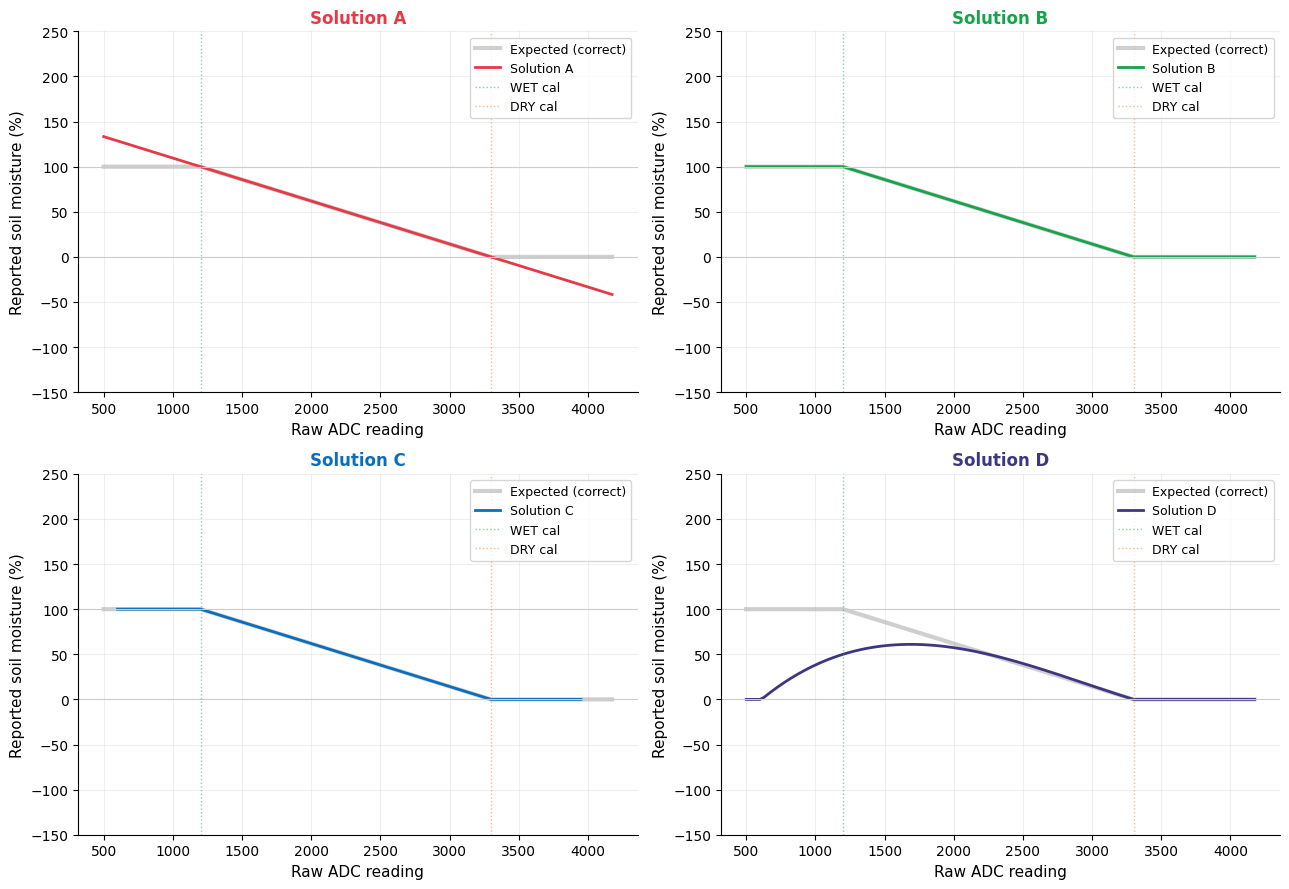

In [9]:
def expected(raw_adc):
    """The reference correct implementation."""
    DRY, WET = 3300, 1200
    pct = 100 * (DRY - raw_adc) / (DRY - WET)
    return max(0.0, min(100.0, pct))

raw_range = np.arange(500, 4200, 25)
expected_vals = [expected(r) for r in raw_range]
A = [read_soil_moisture_A(r) for r in raw_range]
B = [read_soil_moisture_B(r) for r in raw_range]
C = [read_soil_moisture_C(r) if read_soil_moisture_C(r) is not None else np.nan for r in raw_range]
D = [read_soil_moisture_D(r) for r in raw_range]

fig, axes = plt.subplots(2, 2, figsize=(13, 9), facecolor='white')

for ax, label, vals, col in zip(axes.flat,
                                  ['Solution A', 'Solution B', 'Solution C', 'Solution D'],
                                  [A, B, C, D],
                                  [RED, GREEN, BLUE, PURPLE]):
    ax.plot(raw_range, expected_vals, color='#888', lw=3, alpha=0.4, label='Expected (correct)')
    ax.plot(raw_range, vals, color=col, lw=2, label=label)
    ax.axhline(0, color='#ccc', lw=0.8); ax.axhline(100, color='#ccc', lw=0.8)
    ax.axvline(1200, color=GREEN, ls=':', lw=1, alpha=0.5, label='WET cal')
    ax.axvline(3300, color=ORANGE, ls=':', lw=1, alpha=0.5, label='DRY cal')
    ax.set_xlabel('Raw ADC reading', fontsize=11)
    ax.set_ylabel('Reported soil moisture (%)', fontsize=11)
    ax.set_title(label, fontsize=12, fontweight='bold', color=col)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.2)
    ax.set_ylim(-150, 250)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---
## ✏️ Your Task: Diagnose Each Solution

Edit the markdown cell below with your analysis. For each solution, identify:

1. **Is it correct?** (Yes / Partial / No)
2. **Which failure mode does it exhibit?** (none / hallucinated pins / wrong library / off-by-one / plausible nonsense / security gap)
3. **What is the specific bug?**
4. **What would a real-world consequence be if this code triggered a landslide alert?**

---

### Your Diagnosis

**Student name:** [Your name here]

#### Solution A
- Correct? *[Yes / Partial / No]*
- Failure mode: *[...]*
- Bug: *[...]*
- Consequence: *[...]*

#### Solution B
- Correct? *[...]*
- Failure mode: *[...]*
- Bug: *[...]*
- Consequence: *[...]*

#### Solution C
- Correct? *[...]*
- Failure mode: *[...]*
- Bug: *[...]*
- Consequence: *[...]*

#### Solution D
- Correct? *[...]*
- Failure mode: *[...]*
- Bug: *[...]*
- Consequence: *[...]*

---
## Part 2 — Now Write Your Own Prompt

You will now write a prompt for your **own LLM of choice** (Claude, ChatGPT, Copilot, Gemini, etc.) for the following task:

> *Write MicroPython code for an ESP32 that reads the MPU6050 over I²C, computes the tilt angle from vertical in degrees, and publishes the result every 5 seconds to MQTT topic `digihaz/{your_name}/tilt`.*

Follow the **six ingredients** of a good prompt:

1. Board
2. Sensor model
3. Interface and pin
4. Timing
5. Calibration or units
6. Output destination

### Your Prompt

Replace this text with the prompt you actually used. Then paste the **full LLM response** below it.

```
[Write a complete, robust MicroPython script for an ESP32 board.
The script must read data from an MPU6050 sensor using the I2C interface. Please use standard ESP32 pins: SDA on GPIO 21 and SCL on GPIO 22, and use the standard MPU6050 I2C address of 0x68.
Every 5 seconds, the script should wake the sensor, read the raw accelerometer values (X, Y, Z), and calculate the tilt angle from vertical in degrees (using math.atan2 and converting radians to degrees).
Finally, connect to Wi-Fi and publish this computed angle to an MQTT broker. The output destination must be the exact topic: digihaz/azlan/tilt.
Please ensure the code includes basic error handling for Wi-Fi connection, MQTT connection, and I2C communication failures]
```

### The LLM Response

```python
import machine
import time
import math
import network
from umqtt.simple import MQTTClient

# --- Configuration ---
WIFI_SSID = "YOUR_WIFI_SSID"
WIFI_PASS = "YOUR_WIFI_PASSWORD"
MQTT_BROKER = "broker.hivemq.com" # Public test broker
MQTT_PORT = 1883
MQTT_CLIENT_ID = "esp32_azlan_tilt"
MQTT_TOPIC = "digihaz/azlan/tilt"

# --- Hardware Setup ---
i2c = machine.I2C(0, sda=machine.Pin(21), scl=machine.Pin(22))
MPU_ADDR = 0x68

def connect_wifi():
    wlan = network.WLAN(network.STA_IF)
    wlan.active(True)
    if not wlan.isconnected():
        print('Connecting to network...')
        wlan.connect(WIFI_SSID, WIFI_PASS)
        # Wait for connection
        start = time.time()
        while not wlan.isconnected():
            time.sleep(1)
            if time.time() - start > 15:
                raise Exception("Wi-Fi connection timed out")
    print('Network config:', wlan.ifconfig())

def init_mpu6050():
    try:
        # Wake up MPU6050 (clear sleep bit in PWR_MGMT_1 register 0x6B)
        i2c.writeto_mem(MPU_ADDR, 0x6B, b'\x00')
        time.sleep_ms(100)
        print("MPU6050 initialized successfully.")
    except Exception as e:
        print(f"Error initializing MPU6050: {e}")

def read_accelerometer():
    try:
        # Read 6 bytes starting from ACCEL_XOUT_H (0x3B)
        data = i2c.readfrom_mem(MPU_ADDR, 0x3B, 6)
        
        # Convert raw bytes to signed 16-bit integers
        ax = (data[0] << 8) | data[1]
        if ax > 32767: ax -= 65536
        ay = (data[2] << 8) | data[3]
        if ay > 32767: ay -= 65536
        az = (data[4] << 8) | data[5]
        if az > 32767: az -= 65536
        
        return ax, ay, az
    except Exception as e:
        print(f"I2C Read Error: {e}")
        return None

def calculate_tilt(ax, ay, az):
    # Calculate tilt angle from the vertical (Z-axis)
    horizontal_acc = math.sqrt(ax**2 + ay**2)
    tilt_rad = math.atan2(horizontal_acc, az)
    return math.degrees(tilt_rad)

def main():
    connect_wifi()
    init_mpu6050()
    
    client = MQTTClient(MQTT_CLIENT_ID, MQTT_BROKER, MQTT_PORT)
    
    try:
        client.connect()
        print("Connected to MQTT Broker")
    except Exception as e:
        print(f"MQTT Connection Error: {e}")
        return

    while True:
        try:
            accel_data = read_accelerometer()
            if accel_data:
                ax, ay, az = accel_data
                tilt = calculate_tilt(ax, ay, az)
                
                # Publish to MQTT
                payload = f"{tilt:.2f}"
                client.publish(MQTT_TOPIC, payload)
                print(f"Published tilt: {payload}° to {MQTT_TOPIC}")
                
        except Exception as e:
            print(f"Loop Error: {e}")
            # Attempt to reconnect MQTT if it drops
            try:
                client.connect()
            except:
                pass
                
        time.sleep(5)

if __name__ == "__main__":
    main()
```

### Code Review

Now review the generated code line by line. Answer these questions:

1. **Pin assignments** — does the I²C use the standard ESP32 pins (SDA=GPIO21, SCL=GPIO22)? If not, are the chosen pins valid?

> *Yes. The code explicitly defines i2c = machine.I2C(0, sda=machine.Pin(21), scl=machine.Pin(22)). GPIO 21 and 22 are the standard default hardware I2C pins for the ESP32, making this a valid and optimal choice.Yes. The code explicitly defines i2c = machine.I2C(0, sda=machine.Pin(21), scl=machine.Pin(22)). GPIO 21 and 22 are the standard default hardware I2C pins for the ESP32, making this a valid and optimal choice.*

2. **I²C address** — is the MPU6050 address correct (default 0x68)?

> *Yes. The code sets MPU_ADDR = 0x68. This is the correct default 7-bit I2C address for the MPU6050 when the AD0 (Address Select) pin is pulled low (which is the standard configuration for most breakout boards).*

3. **Tilt formula** — does it use `atan2` of the accelerometer values? Or just `atan`? Are the units (radians vs. degrees) correct?

> *Yes, it is implemented correctly. It calculates the horizontal magnitude (math.sqrt(ax**2 + ay**2)) and correctly passes it as the first argument (Y-axis) to math.atan2, with the vertical Z-axis (az) as the second argument (X-axis). This correctly computes the angle from the vertical. Furthermore, it correctly converts the output from radians to degrees using math.degrees().*

4. **MQTT credentials** — are any passwords or broker URLs hard-coded? Is TLS used?

> *Yes, the Wi-Fi SSID, Wi-Fi password, and the MQTT broker URL (broker.hivemq.com) are hard-coded as placeholders at the top of the script. No, TLS is not used. The code connects to port 1883, which is the standard unencrypted MQTT port. Secure MQTT (MQTTS) would require port 8883 and the implementation of SSL/TLS certificates, which are omitted here.*

5. **Error handling** — what happens if WiFi disconnects or the MQTT publish fails?

> *The error handling is partially implemented but has critical gaps for a production IoT device:

    Wi-Fi Disconnect: The script checks for Wi-Fi at boot with a 15-second timeout. However, it does not check for Wi-Fi drops inside the main while True loop. If the Wi-Fi disconnects during operation, the script will continue trying to publish to MQTT, fail, and never attempt to reconnect the Wi-Fi radio.
    
    MQTT Publish Failure: If client.publish() fails, the except block catches it and attempts to call client.connect(). However, if the underlying Wi-Fi is down, this MQTT reconnect will also fail. The nested except: pass silently swallows this error, meaning the device will enter a "zombie state"—looping every 5 seconds, failing to publish, and never recovering without a hard reboot.*

---
## Part 3 — Final Reflection (250 words)

Based on Parts 1 and 2 of this notebook:

### Final Reflection

Write a 250-word reflection on these questions:

1. Which parts of your IoT code would you happily trust to an LLM?
2. Which parts would you always review carefully?
3. How did your view of "AI-assisted coding" change from before this lab to after?
4. If you were submitting research that used vibe-coded sensor firmware, what would you disclose in your methodology?

> *[Your reflection here — 250 words minimum]*

---

*DigiHaz Module 7 — Notebook 2 of 3 (assessed) | github.com/Digihaz/digihaz-course-materials/tree/dev/module_07_iot_sensor_networks/topic_04*

**Submission:** File → Save → upload the completed `.ipynb` to Moodle Module 7 assignment.